Лабораторна робота No5. Методи кластеризації 

In [227]:
import pandas as pd
df = pd.read_csv("ЛР5-пгр2.csv", sep=";")
df.shape

(1599, 12)

In [228]:
df = df.drop("quality", axis=1)
df.columns.tolist()


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [229]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df) 

kmeans = KMeans(n_clusters=3, n_init=10)  #random_state=42
kmeans.fit(X_scaled)

print("Координати центрів кластерів:")
print(kmeans.cluster_centers_)

Координати центрів кластерів:
[[-0.64954342  0.45519175 -0.76049371 -0.23041486 -0.18882329 -0.22156028
  -0.35074257 -0.45100943  0.61490553 -0.28814064  0.0678794 ]
 [ 1.00398862 -0.68568878  1.02077194  0.03104975  0.27616274 -0.47686049
  -0.48168723  0.43844069 -0.75207155  0.55462042  0.28259117]
 [-0.09193154  0.04040678  0.10002523  0.40375126 -0.00565364  1.06837447
   1.32458255  0.28337592 -0.17924274 -0.1874165  -0.51052828]]


In [230]:
import pandas as pd

centers = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns)
print("Координати центрів кластерів (стандартизовані):")
print(centers)

Координати центрів кластерів (стандартизовані):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0      -0.649543          0.455192    -0.760494       -0.230415  -0.188823   
1       1.003989         -0.685689     1.020772        0.031050   0.276163   
2      -0.091932          0.040407     0.100025        0.403751  -0.005654   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            -0.221560             -0.350743 -0.451009  0.614906  -0.288141   
1            -0.476860             -0.481687  0.438441 -0.752072   0.554620   
2             1.068374              1.324583  0.283376 -0.179243  -0.187416   

    alcohol  
0  0.067879  
1  0.282591  
2 -0.510528  


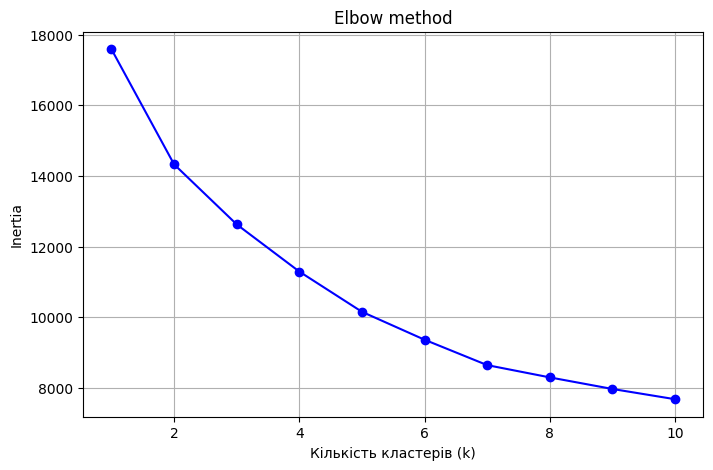

In [231]:
import matplotlib.pyplot as plt

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.grid()
plt.show()


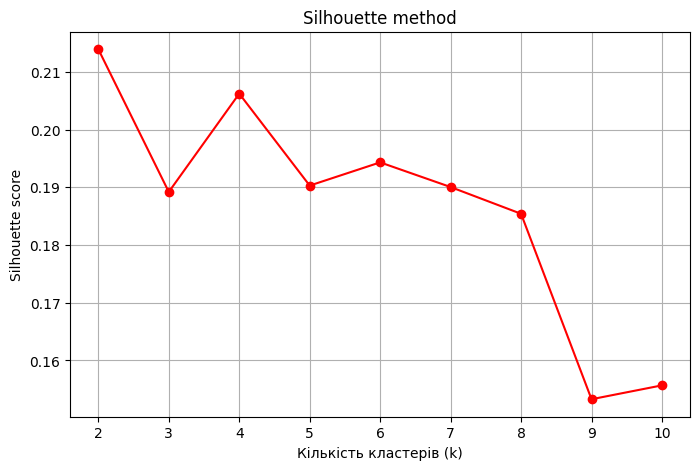

In [232]:
from sklearn.metrics import silhouette_score

silhouette = []

for k in range(2, 11):  # silhouette не працює для k=1
    kmeans = KMeans(n_clusters=k, n_init=10)  #  random_state=42
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette, 'ro-')
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette method')
plt.grid()
plt.show()


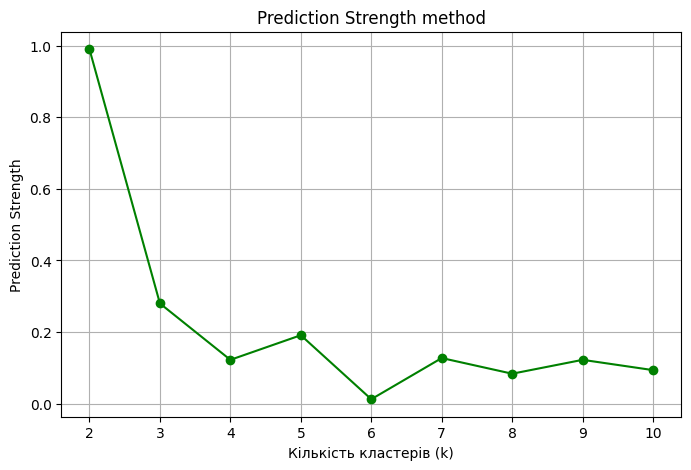

In [233]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances_argmin_min
import numpy as np

def prediction_strength(X, k, test_size=0.5, ):
    X1, X2 = train_test_split(X, test_size=test_size, )

    kmeans1 = KMeans(n_clusters=k,).fit(X1)
    kmeans2 = KMeans(n_clusters=k, ).fit(X2)

    # Знаходимо центри з першої частини для другої
    labels2_proj = pairwise_distances_argmin_min(X2, kmeans1.cluster_centers_)[0]
    strength = np.mean(labels2_proj == kmeans2.labels_)
    return strength

K = range(2, 11)
strength_scores = []

for k in K:
    score = prediction_strength(X_scaled, k,)
    strength_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K, strength_scores, 'go-')
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Prediction Strength')
plt.title('Prediction Strength method')
plt.grid()
plt.show()


In [236]:
inertia_list = []

for i in range(10):  # 10 запусків
    kmeans = KMeans(n_clusters=2, init='k-means++', n_init=1)
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)

# Вивід результатів
print("Inertia при кожному запуску:")
print(inertia_list)

print("\nСередня інерція:", np.mean(inertia_list))
print("Стандартне відхилення:", np.std(inertia_list))
cv_inertia = (np.std(inertia_list)/ np.mean(inertia_list)) * 100
print("Відносне стандартне відхилення:", round(cv_inertia, 2), "%")


Inertia при кожному запуску:
[14330.185297691216, 14330.185297691214, 14330.185297691214, 14330.940238807485, 14331.710519028162, 14331.62253122263, 14331.62253122263, 14330.142460204968, 14331.57612537458, 14331.802307172795]

Середня інерція: 14330.99726061069
Стандартне відхилення: 0.7060903055494667
Відносне стандартне відхилення: 0.0 %


In [239]:
from sklearn.cluster import AgglomerativeClustering

# Ієрархічна кластеризація
agg_clustering = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = agg_clustering.fit_predict(X_scaled)

# Додаємо мітки до таблиці
df_clusters = pd.DataFrame(X_scaled, columns=df.columns)
df_clusters['Cluster'] = labels

# Обчислюємо центри кластерів (середнє по кожному кластеру)
centers = df_clusters.groupby('Cluster').mean().values

# Рахуємо "інерцію" вручну:
inertia = 0

for i in range(2):  # н кластерів
    cluster_points = X_scaled[labels == i]
    center = centers[i]
    inertia += np.sum((cluster_points - center) ** 2)

print("Координати центрів кластерів (в стандартизованих даних):")
print(centers)

print("Інерція для AgglomerativeClustering:", inertia)


Координати центрів кластерів (в стандартизованих даних):
[[-0.33671193  0.33282136 -0.42987265  0.01367412 -0.10956403  0.24047937
   0.24867327 -0.08468829  0.2637072  -0.20807042 -0.18530765]
 [ 0.77339607 -0.76445977  0.98737758 -0.03140818  0.25165841 -0.5523588
  -0.57117942  0.19452115 -0.60571097  0.47791845  0.42563447]]
Інерція для AgglomerativeClustering: 15035.91667453838
